In [2]:
# import pandas as pd
# import settings

# print("loading metadata for object and location category")
# metadata_df = pd.read_csv(settings.metadata_path)
# object_dict = {row['ImageID']: set(row['object'].split(',')) for _, row in metadata_df.iterrows() if not pd.isna(row['object'])}
# loccat_dict = {row['ImageID']: set(row['categories'].split(',')) for _, row in metadata_df.iterrows() if not pd.isna(row['categories'])}

In [3]:
# print(type(object_dict))
# # PRINT SIZE OF DICTIONARY
# print(len(object_dict))

In [4]:
# import spacy
# from textblob import TextBlob

# # parse objects and location categories from query
# def parse_objects_from_query(query):

#     # Process our query
#     print(query)
#     nlp = spacy.load("en_core_web_sm")
#     doc = nlp(query)

#     # Use blob to find words that are normal nouns
#     blob = TextBlob(doc.text)
#     all_nouns = [word for word, tag in blob.tags if tag in ['NN', 'NNS']]
    

#     # Extract noun_chunks, then extract the root from each noun_chunk
#     all_noun_chunks = [chunk.text for chunk in doc.noun_chunks if str(chunk.root) in all_nouns]
#     print(all_noun_chunks)
#     return all_noun_chunks

# text_query = "Mother Mary, pray for usâ€¦ A religious image in front of a window on a Saturday morning in Dublin City University after coffee and before a second coffee in a different cafe. It was the last day of August."
# parse_objects_from_query(text_query)

In [5]:
# ! pip install -U sentence-transformers

In [2]:
print("setting up!")
from helper import setup
print("setup done!")

print(setup.OFFSET_OBJECT_START, setup.OFFSET_OBJECT_END, setup.OFFSET_LOCATION_START, setup.OFFSET_LOCATION_END)

setting up!
loading keyframe paths
Done loading keyframe paths in 14.378895044326782 seconds.

loading sentence-transformers model
Done loading sentence-transformers model in 22.711071968078613 seconds.

loading caption git index
Done loading caption git index in 44.74507212638855 seconds.

loading object blip2 index
Done loading object blip2 index in 44.80129313468933 seconds.

loading nlp parser
Done loading nlp parser in 49.57288980484009 seconds.

loading object list and location category list
Done loading object and location category list in 51.093815088272095 seconds.

loading metadata for object and location category
Done loading metadata in 152.4104413986206 seconds.

loading fuzzy index for location search
Done loading fuzzy index in 152.71443104743958 seconds.

setup done!
0 402 402 655


In [9]:
from helper import embedding_helper, fuzzy_search
from importlib import reload
reload(embedding_helper)
reload(fuzzy_search)
# text_query = "Mother Mary, pray for us... A religious image in front of a window on a Saturday morning in Dublin City University"
# text_query = "Mother Mary, pray for us... A religious image in front of a window on a Saturday morning in Dublin City University after coffee and before a second coffee in a different cafe. It was the last day of August."
# text_query = "I was praying to small golden Buddha"
# text_query = "I was praying to small golden Buddha in a tunnel. "
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. "
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. It was inside of a tourist park with a large ornamental tower."
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. It was inside of a tourist park with a large ornamental tower. It was in September 2019 "
# text_query = "In disaster prepper-mode, I was buying an oversized tin of beans, incase of emergencies when covid was starting. I had looked at many large food items "
# text_query = "tins of beans, in a warehouse store called Musgrave MarketPlace"
# text_query = "Lots of colourful mugs for sale"
# text_query = "Lots of colourful mugs for sale. Yellow, red, green, blue, orange cups. "
# text_query = "colourful mugs beside some green plants in an outdoor mall"
# text_query = "I think it was the second time I visited the house with the stone shed or hovel.  The shed was under green trees on a beautiful sunny day. "
text_query = "I think it was the second time I visited the house with the stone shed or hovel.  The shed was under green trees on a beautiful sunny day. It takes 2 hours to drive there and two hours to drive back home. It was in the middle of Ireland on the 29th April 2020."
image_path = "E:\\LSCDATA\\keyframes\\202001\\10\\20200110_005948_000.jpg"

# Search bằng text query, mode = "caption" hoặc "image"
# paths = embedding_helper.search_by_text_query(setup.keyframe_paths, "caption", text_query)
# paths = embedding_helper.search_by_text_query(setup.keyframe_paths, "image", text_query)
# Search bằng image path
paths = embedding_helper.search_by_image_path(setup.keyframe_paths, image_path)

In [ ]:
paths

In [ ]:
import settings
from importlib import reload
reload(settings)


print("loading blip2 model")
from torch import hub
hub.set_dir(settings.blip2_model_path)
import torch
from lavis.models import load_model_and_preprocess
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, vis_processors, txt_processors = load_model_and_preprocess(name="blip2_feature_extractor", model_type="pretrain", is_eval=True, device=device)

loading blip2 model


In [ ]:
import faiss
import settings
from importlib import reload
reload(settings)

blip2_index = faiss.read_index(settings.blip2_index_path, faiss.IO_FLAG_MMAP|faiss.IO_FLAG_READ_ONLY)


In [3]:
dimension = blip2_index.d
embeddings = faiss.rev_swig_ptr(blip2_index.get_xb(), num_docs*dimension).reshape(num_docs, dimension)

print(blip2_index.get_xb().at(529764))

AttributeError: 'SwigPyObject' object has no attribute 'at'

In [ ]:
# import base64
# import io
# from PIL import Image

# image_path = "E:\\LSCDATA\\keyframes\\202001\\10\\20200110_005948_000.jpg"

# with open(image_path, "rb") as image_file:
#     encoded_string = base64.b64encode(image_file.read())
#     data = {'image': encoded_string.decode('utf-8')}
# encoded_image_bytes = data["image"]
# print(type(encoded_image_bytes))
# image_bytes = base64.b64decode(encoded_image_bytes)

# raw_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
# image = vis_processors["eval"](raw_image).unsqueeze(0).to(device)
# print(image.size())
# sample = {"image": image, "text_input": []}
# features_image = model.extract_features(sample, mode="image").image_embeds[:, 0, :]
# print(features_image.tolist())

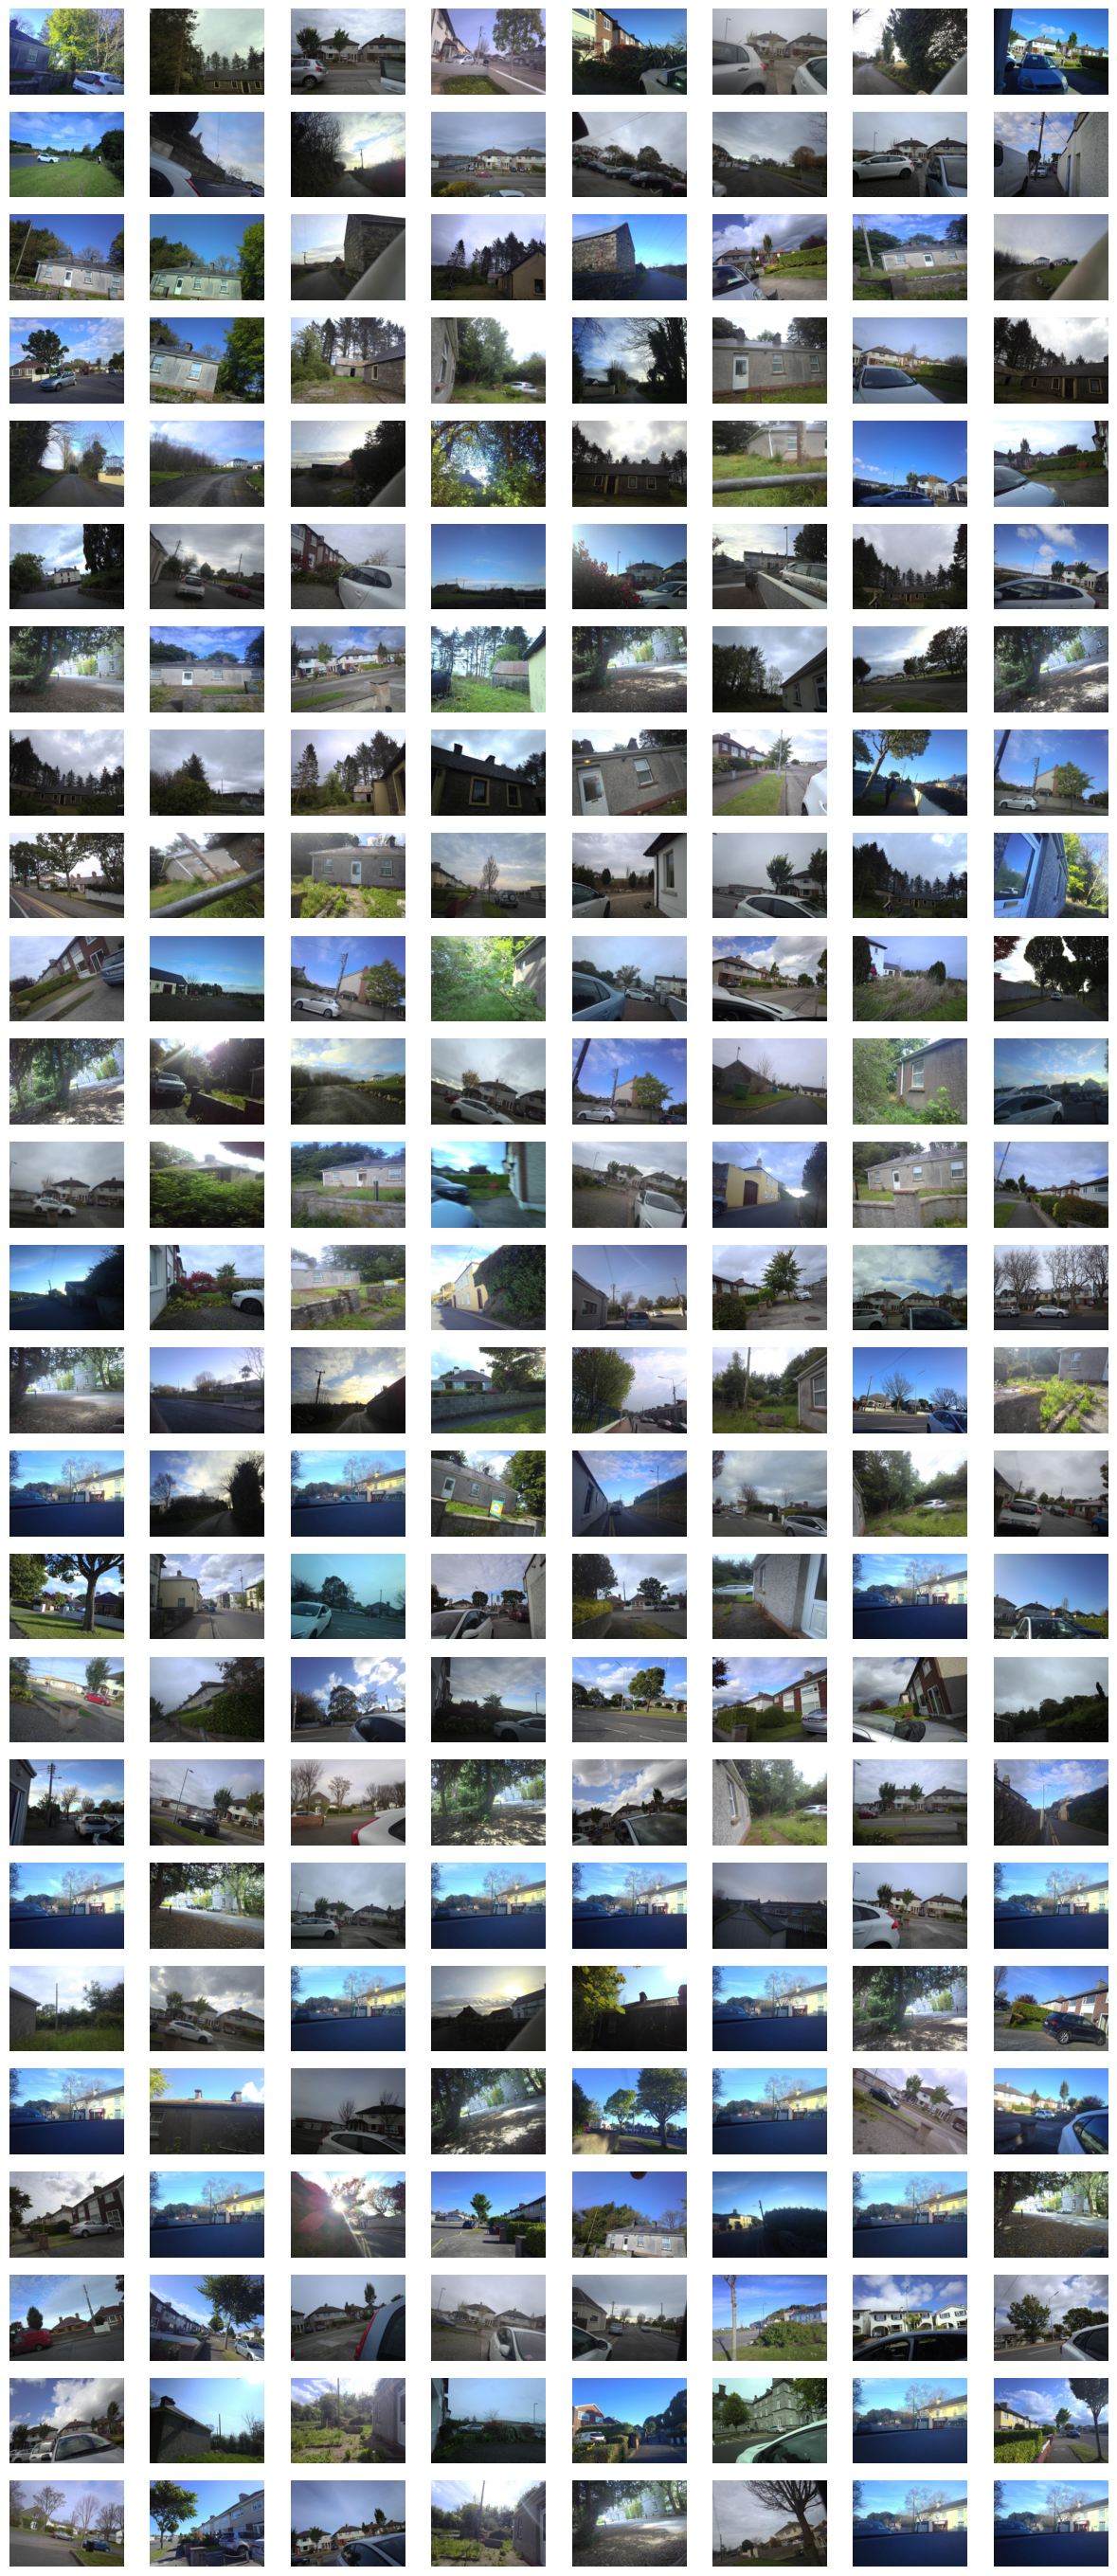

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 270))
img_count = 1

for path in paths[:200]:
    try:
        img = Image.open(path)
    except:
        continue    
    resize = (160, 120)
    img = img.resize(resize)
    plt.subplots_adjust(bottom=0.2, top=0.3)
    ax = plt.subplot(25, 8, img_count)
    ax.axis('off')
    plt.imshow(img)
    img_count += 1

In [ ]:
import settings

print("loading blip2 model")
from torch import hub
hub.set_dir(settings.blip2_model_path)
import torch
from lavis.models import load_model_and_preprocess
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, vis_processors, txt_processors = load_model_and_preprocess(name="blip2_feature_extractor", model_type="pretrain", is_eval=True, device=device)
# print(f"Done loading blip2 model in {time.time() - start_time} seconds.\n")

loading blip2 model


In [ ]:
txt = txt_processors["eval"](text_query)
text_sample = {"image":  [], "text_input": [txt]}
text_embedding = model.extract_features(text_sample, mode="text").text_embeds[:, 0, :]

text_embedding.shape

NameError: name 'txt_processors' is not defined

In [3]:
import numpy as np

txtembd = np.array([
            0.11625441908836365,
            0.3846547603607178,
            0.06908602267503738,
            -0.15222333371639252,
            0.1264553964138031,
            0.09338737279176712,
            0.013450847007334232,
            0.05642024055123329,
            0.3377249836921692,
            -0.009506338275969028,
            0.12611153721809387,
            0.4223769009113312,
            0.19188493490219116,
            0.38228416442871094,
            0.20707227289676666,
            0.15292097628116608,
            0.5005459785461426,
            0.011634182184934616,
            -0.1640535295009613,
            -0.2733871638774872,
            -0.19530585408210754,
            -0.2885880172252655,
            -0.12654301524162292,
            0.11954931169748306,
            -0.37539005279541016,
            -0.14863206446170807,
            0.1657499223947525,
            -0.05275232717394829,
            0.08155468851327896,
            0.24396264553070068,
            0.03706767037510872,
            -0.015076532028615475,
            -0.11169259250164032,
            0.22600197792053223,
            0.15894952416419983,
            0.26387783885002136,
            0.19527983665466309,
            0.1176328957080841,
            -0.3973780572414398,
            0.09305563569068909,
            -0.03177732601761818,
            -0.015714794397354126,
            -0.02066728286445141,
            -0.12988866865634918,
            -0.3379153907299042,
            -0.00035266880877316,
            -0.18467895686626434,
            0.04162120074033737,
            -0.24503739178180695,
            -0.016626939177513123,
            -0.16077342629432678,
            -0.11725185066461563,
            0.2530900239944458,
            0.14851832389831543,
            -0.2905833423137665,
            -0.0020348194520920515,
            -0.34372302889823914,
            -0.26147058606147766,
            -0.21099212765693665,
            -0.15276555716991425,
            -0.17504502832889557,
            -0.13460485637187958,
            0.34458181262016296,
            0.027671223506331444,
            0.030999643728137016,
            0.29552045464515686,
            -0.03132186457514763,
            0.023663101717829704,
            -0.19710195064544678,
            0.0415678508579731,
            -0.05683213844895363,
            -0.025836555287241936,
            -0.26156923174858093,
            0.2937867045402527,
            0.04926396533846855,
            0.11778342723846436,
            0.0021893205121159554,
            -0.15492668747901917,
            0.06170682981610298,
            -0.1006024107336998,
            -0.011366627179086208,
            0.009553283452987671,
            -0.26787784695625305,
            -0.1660391092300415,
            -0.12071368843317032,
            -0.10403983294963837,
            0.08603724092245102,
            0.047348909080028534,
            -0.015122570097446442,
            0.24362948536872864,
            -0.5427792072296143,
            -0.12219161540269852,
            -0.2357829064130783,
            -0.11651146411895752,
            -0.21362866461277008,
            0.04369698837399483,
            0.3533245325088501,
            0.22963784635066986,
            0.2363271266222,
            -0.19185923039913177,
            -0.010347985662519932,
            -0.5984714031219482,
            -0.14813873171806335,
            0.09638459980487823,
            -0.3808463215827942,
            -0.025796905159950256,
            0.3345381021499634,
            0.049149882048368454,
            0.23145902156829834,
            0.017770856618881226,
            -0.04622109606862068,
            0.18767009675502777,
            0.31149762868881226,
            0.0993444100022316,
            -0.3348536193370819,
            0.10216085612773895,
            0.26075488328933716,
            -0.18084722757339478,
            0.16849887371063232,
            -0.22181643545627594,
            0.1325056254863739,
            -0.008648565039038658,
            0.1544521600008011,
            0.06366975605487823,
            -0.004164521116763353,
            0.027083393186330795,
            0.1227390319108963,
            -0.04832773655653,
            -0.13071750104427338,
            -0.15012338757514954,
            0.07625558227300644,
            0.014408976770937443,
            -0.12374680489301682,
            -0.23019075393676758,
            -0.000724632409401238,
            -0.10591141134500504,
            0.016407117247581482,
            -0.04379308223724365,
            -0.26515093445777893,
            -0.059750743210315704,
            -0.12257625162601471,
            0.14423121511936188,
            0.004408960696309805,
            -0.09289273619651794,
            -0.06128411367535591,
            -0.2559470236301422,
            -0.29673388600349426,
            0.08458548784255981,
            0.2504018247127533,
            -0.3288133144378662,
            -0.12734133005142212,
            0.31324490904808044,
            0.23208922147750854,
            0.3799281120300293,
            0.18575358390808105,
            -0.04518990218639374,
            0.07208552211523056,
            -0.07790014892816544,
            -0.3457512855529785,
            0.3186977505683899,
            0.5206832885742188,
            0.03539897873997688,
            0.1781313717365265,
            -0.08559571951627731,
            0.31010541319847107,
            0.07106643170118332,
            0.05552798882126808,
            -0.2109585702419281,
            0.01854059100151062,
            0.44503265619277954,
            0.06931626051664352,
            -0.010092975571751595,
            0.09611189365386963,
            -0.022011803463101387,
            -0.18397219479084015,
            -0.43441715836524963,
            -0.3736840784549713,
            -0.11240575462579727,
            -0.004738808609545231,
            -0.1707405000925064,
            0.0995226800441742,
            0.20026831328868866,
            0.10361529141664505,
            -0.06314345449209213,
            -0.17633984982967377,
            0.030373547226190567,
            0.15433180332183838,
            -0.2061479091644287,
            -0.13565251231193542,
            0.2690698206424713,
            -0.2464287430047989,
            -0.012777958996593952,
            0.45367202162742615,
            0.1988675594329834,
            0.1111752912402153,
            -0.18157507479190826,
            0.14169250428676605,
            0.06511272490024567,
            0.12038418650627136,
            0.3306780159473419,
            0.3540273606777191,
            -0.012545963749289513,
            0.0017825709655880928,
            -0.00998762808740139,
            0.160980686545372,
            0.25415360927581787,
            -0.10185907781124115,
            0.07826434820890427,
            -0.011250085197389126,
            0.2746867835521698,
            -0.1413165181875229,
            -0.020381422713398933,
            0.2688755989074707,
            0.05684724077582359,
            0.06563998013734818,
            0.11649320274591446,
            0.38749027252197266,
            0.1409287452697754,
            0.07146768271923065,
            -0.013413660228252411,
            -0.03453192487359047,
            0.13083359599113464,
            0.1564623862504959,
            0.14971482753753662,
            0.2503993511199951,
            0.20596769452095032,
            0.38984400033950806,
            0.15859587490558624,
            0.16988828778266907,
            -0.3530404567718506,
            -0.23327669501304626,
            0.27469706535339355,
            -0.0009022873127833009,
            0.38058018684387207,
            0.1643284559249878,
            0.031657423824071884,
            0.3294895589351654,
            -0.15041454136371613,
            0.1722586750984192,
            -0.09183662384748459,
            -0.18909794092178345,
            -0.04108813777565956,
            0.09991535544395447,
            0.21149078011512756,
            -0.1309996247291565,
            -0.062217265367507935,
            -0.09594623744487762,
            -0.33250299096107483,
            0.08109789341688156,
            -0.07023106515407562,
            -0.40834733843803406,
            0.3290368914604187,
            -0.0769943967461586,
            -0.027878111228346825,
            0.11755716800689697,
            0.08840043097734451,
            -0.019706452265381813,
            -0.1301639825105667,
            0.06334662437438965,
            0.3470323085784912,
            -0.1210680603981018,
            0.15783482789993286,
            -0.07911098003387451,
            -0.30571869015693665,
            -0.4119291305541992,
            -0.33342379331588745,
            -0.11950208991765976,
            0.08563242852687836,
            -0.06852049380540848,
            -0.162027508020401,
            -0.10926039516925812,
            0.061084188520908356,
            -0.052402086555957794,
            -0.15273374319076538,
            0.05415397509932518,
            0.015112407505512238,
            0.30553391575813293,
            -0.22637784481048584,
            -0.2232515960931778,
            0.33448514342308044,
            -0.08044354617595673,
            -0.06641868501901627,
            0.04494612291455269,
            -0.07785817980766296,
            0.012727637775242329,
            -0.40848687291145325,
            0.024499475955963135,
            -0.34904706478118896,
            -0.09813742339611053,
            0.4834147095680237,
            0.0004379634920042008,
            -0.5159561634063721,
            -0.25835639238357544,
            0.1213282123208046,
            0.26267004013061523,
            0.11409909278154373,
            -0.010925781913101673,
            0.2292596846818924,
            -0.5315650701522827,
            0.5958567261695862,
            0.2674333453178406,
            0.4854743480682373,
            -0.17363378405570984,
            0.5246292352676392,
            -0.03602166473865509,
            -0.08207429200410843,
            -0.25091081857681274,
            -0.001908554113470018,
            -4.973893642425537,
            -0.15315845608711243,
            -0.0318327471613884,
            -0.08193836361169815,
            0.19623060524463654,
            -0.1092834621667862,
            -0.09886135905981064,
            -0.0840514525771141,
            -0.25248607993125916,
            0.2611125409603119,
            -0.05692039802670479,
            -0.04809072986245155,
            -0.10144305229187012,
            0.07119539380073547,
            0.06153418496251106,
            -0.2065768986940384,
            -0.15295419096946716,
            -0.035270847380161285,
            -0.06964415311813354,
            -0.004790893755853176,
            -0.10259737819433212,
            0.06868468225002289,
            0.02712087333202362,
            -0.07855088263750076,
            0.02284327894449234,
            0.23042677342891693,
            -0.42421042919158936,
            0.09514245390892029,
            0.056013960391283035,
            -0.10000201314687729,
            -0.19677218794822693,
            -0.4416922926902771,
            0.38166090846061707,
            0.03789316862821579,
            0.12140282243490219,
            -0.012651653960347176,
            0.21550196409225464,
            -0.061925772577524185,
            -0.25183114409446716,
            0.007724128197878599,
            -0.47856777906417847,
            -0.20730693638324738,
            -0.20123803615570068,
            -0.09564642608165741,
            -0.23631218075752258,
            0.28920286893844604,
            -0.17975680530071259,
            -0.3883022665977478,
            0.2711349427700043,
            -0.09088809788227081,
            0.08202710002660751,
            0.19030813872814178,
            -0.12628889083862305,
            -0.08568566292524338,
            0.21611753106117249,
            0.23318691551685333,
            0.4094192385673523,
            -0.013975131325423717,
            -0.07955718040466309,
            -0.10767209529876709,
            0.11891767382621765,
            0.0048547168262302876,
            -0.07564732432365417,
            -0.2919982671737671,
            -0.027396420016884804,
            -0.09837878495454788,
            0.018944738432765007,
            -0.05068863928318024,
            0.3011816442012787,
            -0.11573239415884018,
            -0.03259574621915817,
            0.12655654549598694,
            0.23064598441123962,
            -0.20657581090927124,
            0.13381299376487732,
            -0.023042254149913788,
            -0.29012903571128845,
            -0.00045616025454364717,
            0.2272779792547226,
            0.04514487832784653,
            -0.1076301857829094,
            0.005943696480244398,
            0.10291824489831924,
            -0.03796599432826042,
            -0.0031240142416208982,
            0.2801625430583954,
            -0.2288861870765686,
            0.2396477609872818,
            -0.002531783888116479,
            -0.28239381313323975,
            -0.2184331715106964,
            0.026355208829045296,
            -0.3943120837211609,
            -0.05115905776619911,
            0.38225850462913513,
            -0.38439130783081055,
            0.09659739583730698,
            -0.043528009206056595,
            -0.23693370819091797,
            0.15402498841285706,
            -0.16668574512004852,
            0.01834702491760254,
            -0.14795656502246857,
            0.03137637674808502,
            -0.05013492330908775,
            0.051881708204746246,
            0.015051821246743202,
            0.37029826641082764,
            -0.1647462546825409,
            -0.19816692173480988,
            0.09050970524549484,
            0.10584918409585953,
            0.39286068081855774,
            0.09243905544281006,
            -0.2856336236000061,
            -0.5120725035667419,
            0.025269439443945885,
            0.038996562361717224,
            -0.03766503185033798,
            0.001816228381358087,
            -0.15988945960998535,
            0.03812494874000549,
            -0.1039450615644455,
            0.03737678378820419,
            -0.2249842882156372,
            -0.010489212349057198,
            -0.137156143784523,
            -0.20257568359375,
            0.10084018856287003,
            -0.27381631731987,
            -0.2336476445198059,
            -0.3043381869792938,
            0.04281573370099068,
            -0.005006091203540564,
            0.4036954939365387,
            0.1992877721786499,
            0.5031481385231018,
            -0.2430914044380188,
            -0.01434339303523302,
            0.011941096745431423,
            -0.03464505076408386,
            0.13356968760490417,
            -0.23441441357135773,
            -0.03094077855348587,
            -0.45627889037132263,
            -0.18815161287784576,
            0.256721556186676,
            -0.08575785160064697,
            0.05660862475633621,
            0.07066906243562698,
            0.2298007756471634,
            -0.28126513957977295,
            0.28032606840133667,
            -0.13812896609306335,
            0.4009511172771454,
            -0.015228289179503918,
            -0.11595863103866577,
            -0.1288868486881256,
            0.19299903512001038,
            0.009821377694606781,
            0.1370926946401596,
            0.3992692828178406,
            -0.19148416817188263,
            0.02240232191979885,
            0.1276918649673462,
            -0.12916582822799683,
            0.22215822339057922,
            0.02653258666396141,
            0.19004856050014496,
            0.10215314477682114,
            -0.1806190460920334,
            -0.050359487533569336,
            0.06293385475873947,
            0.26534709334373474,
            0.2143903374671936,
            -0.10782509297132492,
            0.0761854499578476,
            -0.06232212856411934,
            0.2436123490333557,
            0.059244293719530106,
            -0.18250297009944916,
            -0.19525626301765442,
            0.07057920098304749,
            0.22819393873214722,
            0.0672730803489685,
            -0.3787916898727417,
            -0.624194860458374,
            0.042934104800224304,
            0.3284870982170105,
            0.09391027688980103,
            0.15635256469249725,
            -0.02979706972837448,
            0.04614986479282379,
            -0.1924513727426529,
            -0.2657492160797119,
            0.1482522338628769,
            0.05264998972415924,
            -0.33545345067977905,
            -0.07176448404788971,
            0.17281419038772583,
            -0.10803119093179703,
            -0.03966517373919487,
            0.057169701904058456,
            -0.22522930800914764,
            0.21298089623451233,
            -0.04421623796224594,
            -0.002242614980787039,
            -0.10240079462528229,
            0.09092237055301666,
            0.23623301088809967,
            -0.006055749021470547,
            -0.0958704799413681,
            -0.279864639043808,
            0.275940477848053,
            -0.09285006672143936,
            -0.46654167771339417,
            0.3116855025291443,
            0.006168594118207693,
            -0.011859020218253136,
            0.0606796033680439,
            0.2614719569683075,
            -0.21409770846366882,
            -0.13324660062789917,
            0.4043391942977905,
            -0.03232806921005249,
            0.3919498324394226,
            0.16658629477024078,
            -0.00316048227250576,
            -0.17455874383449554,
            0.2896914780139923,
            0.06541221588850021,
            0.22134798765182495,
            -0.07079341262578964,
            0.032999373972415924,
            -0.575901210308075,
            0.03502180054783821,
            -0.05643148720264435,
            -0.16623301804065704,
            -0.18054069578647614,
            0.1684892326593399,
            -0.007878267206251621,
            0.15283121168613434,
            0.20186792314052582,
            0.11002073436975479,
            -0.3113497197628021,
            -0.07803426682949066,
            0.34286031126976013,
            -0.08131822943687439,
            -0.09625987708568573,
            0.3119783401489258,
            0.2078610062599182,
            0.03126709535717964,
            -0.16786952316761017,
            -0.25843045115470886,
            0.23471762239933014,
            -0.443271666765213,
            -0.20712821185588837,
            0.1667911559343338,
            -0.14388029277324677,
            0.16263093054294586,
            -0.1532358080148697,
            -0.26296132802963257,
            0.3148249089717865,
            -0.024489736184477806,
            -0.4388713836669922,
            0.14058616757392883,
            0.10358508676290512,
            -0.3139173984527588,
            -0.00940368976444006,
            -0.4266640841960907,
            -0.18033592402935028,
            0.05641346797347069,
            0.2443503439426422,
            -0.20203913748264313,
            0.40486428141593933,
            -0.24345073103904724,
            0.3576289713382721,
            -0.14603310823440552,
            -0.27185535430908203,
            0.20758043229579926,
            -0.15394240617752075,
            0.19422978162765503,
            -0.30562910437583923,
            0.1369960904121399,
            0.1701471209526062,
            -0.01386196818202734,
            0.18529845774173737,
            0.08296613395214081,
            0.11990167200565338,
            -0.12115836888551712,
            -0.3600139617919922,
            0.22722382843494415,
            0.07738536596298218,
            0.1867285519838333,
            0.05491592362523079,
            -0.17297089099884033,
            -0.15157192945480347,
            -0.08691732585430145,
            -0.06724674999713898,
            0.2375892847776413,
            -0.05588440224528313,
            -0.31131505966186523,
            0.09883495420217514,
            0.06586306542158127,
            0.06951988488435745,
            -0.005250120535492897,
            -0.1569788157939911,
            -0.1881861835718155,
            -0.3409770727157593,
            0.1420537233352661,
            0.07664959877729416,
            0.0822729840874672,
            -0.18579696118831635,
            0.14898791909217834,
            0.40284356474876404,
            -0.03368137776851654,
            0.09768663346767426,
            -0.23367364704608917,
            -0.05346895381808281,
            0.27495530247688293,
            -0.24315179884433746,
            -0.358158677816391,
            0.286018043756485,
            -0.2238612025976181,
            0.020399928092956543,
            -0.2142050415277481,
            0.031162049621343613,
            0.14759205281734467,
            0.050310488790273666,
            0.1517389565706253,
            0.0362677201628685,
            0.2618945837020874,
            0.21728502213954926,
            0.02982925809919834,
            -0.42986786365509033,
            0.01667219027876854,
            0.043340083211660385,
            -0.19392743706703186,
            -0.3025663495063782,
            0.2542036473751068,
            -0.07522138953208923,
            -0.3161311745643616,
            0.0040962668135762215,
            0.03333144634962082,
            0.10731398314237595,
            0.17105427384376526,
            -0.06656354665756226,
            -0.13489356637001038,
            0.5432471632957458,
            0.3859632909297943,
            0.1835184246301651,
            0.21599550545215607,
            -0.5027796626091003,
            -0.009227688424289227,
            0.04081365466117859,
            -0.056774891912937164,
            -0.020967375487089157,
            -0.02776762843132019,
            -0.2098221778869629,
            -0.1135629266500473,
            -0.24329502880573273,
            0.2698807418346405,
            0.1360282003879547,
            0.38693535327911377,
            0.320827454328537,
            -0.005823272746056318,
            0.14616887271404266,
            -0.09004417061805725,
            0.14796780049800873,
            0.3277730941772461,
            0.0751987025141716,
            0.20865468680858612,
            0.07296018302440643,
            -0.03296715021133423,
            0.1629294902086258,
            0.25785350799560547,
            0.21024075150489807,
            0.0005804647225886583,
            0.14496074616909027,
            -0.3829982578754425,
            -0.1011846661567688,
            0.22043375670909882,
            -0.4998377859592438,
            -0.1921251267194748,
            -0.1630743443965912,
            0.2911110520362854,
            0.17849187552928925,
            -0.2343178391456604,
            -0.23738864064216614,
            0.03651786968111992,
            -0.010003093630075455,
            -0.387253075838089,
            0.46712425351142883,
            -0.1791372150182724,
            -0.08993734419345856,
            0.31506606936454773,
            -0.1862565129995346,
            0.1580660492181778,
            -0.24883444607257843,
            -0.17153210937976837,
            0.07178885489702225,
            0.022944018244743347,
            -0.09190420061349869,
            0.01212583389133215,
            -0.3187331557273865,
            0.25962281227111816,
            0.017124975100159645,
            -0.23126712441444397,
            0.1408170908689499,
            0.04165446758270264,
            0.22186031937599182,
            0.2522316575050354,
            -0.09852761775255203,
            0.528918445110321,
            -0.32773056626319885,
            -0.17167940735816956,
            0.047708939760923386,
            0.4889811873435974,
            0.28977692127227783,
            -0.6113643646240234,
            -0.13593070209026337,
            -0.2882094979286194,
            0.1269669532775879,
            -0.35272693634033203,
            0.16709671914577484,
            -0.10926320403814316,
            -0.09093327075242996,
            -0.1929176300764084,
            -0.3052220046520233,
            -0.21225258708000183,
            -0.0568096861243248,
            -0.0538814440369606,
            -0.21904213726520538,
            -0.7713766694068909,
            -0.15739065408706665,
            -0.17349079251289368,
            -0.0598701648414135,
            0.3464134633541107,
            0.06783679127693176,
            0.13220013678073883,
            0.11259978264570236,
            0.21781988441944122,
            0.011580612510442734,
            -0.09967079013586044,
            0.414204478263855,
            -0.008912536315619946,
            0.36241501569747925,
            -0.10245576500892639,
            -0.10952292382717133,
            -0.21601299941539764,
            -0.0026528509333729744,
            0.08617306500673294,
            0.15450234711170197,
            -0.03267474099993706,
            0.25865453481674194,
            -0.39827051758766174,
            0.38485342264175415,
            -0.229562908411026,
            0.1703818142414093,
            -0.042685579508543015
        ])
txtemb2 = np.array([
            0.06406111270189285,
            0.30076128244400024,
            0.15759402513504028,
            -0.2744879126548767,
            0.004232150036841631,
            0.06809145212173462,
            0.044916652143001556,
            0.06883197277784348,
            0.3635668456554413,
            -0.0948544442653656,
            0.14977304637432098,
            0.27087002992630005,
            0.12729474902153015,
            0.3399448096752167,
            0.05055300146341324,
            0.12899276614189148,
            0.4005814790725708,
            0.04359214007854462,
            -0.11664330214262009,
            -0.36443763971328735,
            -0.09496214985847473,
            -0.14913451671600342,
            -0.06898991763591766,
            0.07774825394153595,
            -0.1527986377477646,
            -0.1009989082813263,
            0.11842083185911179,
            -0.08531221747398376,
            0.04181448742747307,
            0.3307305872440338,
            0.20309261977672577,
            -0.08174250274896622,
            -0.13956065475940704,
            0.25491833686828613,
            0.06576666980981827,
            0.2395518571138382,
            0.2041759341955185,
            0.14532262086868286,
            -0.3471916913986206,
            0.1148412898182869,
            -0.07627648860216141,
            0.1050816997885704,
            0.013507222756743431,
            -0.002570854499936104,
            -0.2793019711971283,
            -0.09777560830116272,
            -0.31507590413093567,
            0.02657550573348999,
            -0.2809382975101471,
            0.07433436065912247,
            -0.13327409327030182,
            -0.08268897980451584,
            0.33876264095306396,
            0.23952926695346832,
            -0.35954907536506653,
            0.04307108744978905,
            -0.32914164662361145,
            -0.24885399639606476,
            -0.12599684298038483,
            -0.12332978844642639,
            -0.23689059913158417,
            -0.11504623293876648,
            0.3555159270763397,
            0.12816818058490753,
            0.05849926546216011,
            0.28702589869499207,
            -0.08050518482923508,
            -0.08904490619897842,
            -0.24003373086452484,
            0.10170170664787292,
            -0.02879955619573593,
            -0.1007668748497963,
            -0.3851948082447052,
            0.33562710881233215,
            -0.020274709910154343,
            0.16979636251926422,
            -0.04643120989203453,
            -0.17355604469776154,
            -0.019132450222969055,
            -0.07317379117012024,
            -0.09447690844535828,
            0.005815167911350727,
            -0.2506401836872101,
            -0.21858836710453033,
            -0.12040474265813828,
            -0.10080629587173462,
            0.04611784219741821,
            0.12179875373840332,
            0.0045117903500795364,
            0.34165671467781067,
            -0.5899728536605835,
            -0.1926034390926361,
            -0.11333687603473663,
            -0.08539650589227676,
            -0.13934724032878876,
            0.1549254059791565,
            0.2954072654247284,
            0.1609124094247818,
            0.29186198115348816,
            -0.22482585906982422,
            -0.02995198220014572,
            -0.6923769116401672,
            -0.04884164035320282,
            -0.040003713220357895,
            -0.5068771839141846,
            -0.022139983251690865,
            0.21768222749233246,
            -0.053624559193849564,
            0.27079591155052185,
            0.04401256889104843,
            -0.006276419386267662,
            0.17595426738262177,
            0.3655461370944977,
            0.18975521624088287,
            -0.2609160542488098,
            0.1755179762840271,
            0.3845869302749634,
            -0.19010068476200104,
            0.08119553327560425,
            -0.18731331825256348,
            0.07717622816562653,
            0.12546704709529877,
            0.24999016523361206,
            0.09091842919588089,
            0.07618150860071182,
            -0.043574973940849304,
            0.285296231508255,
            -0.0031289849430322647,
            -0.1749487966299057,
            -0.10288795828819275,
            -0.023699652403593063,
            -0.07126044481992722,
            -0.21836869418621063,
            -0.17506423592567444,
            0.05026836320757866,
            -0.16020968556404114,
            -0.05196013301610947,
            -0.0897907018661499,
            -0.42264920473098755,
            0.1030251607298851,
            -0.10523461550474167,
            0.20314709842205048,
            0.00020097159722354263,
            -0.16684813797473907,
            -0.1419605314731598,
            -0.34341439604759216,
            -0.2473691999912262,
            0.11988437920808792,
            0.2386220097541809,
            -0.40767380595207214,
            -0.11272908747196198,
            0.19195301830768585,
            0.20044554769992828,
            0.441738486289978,
            0.10315384715795517,
            -0.08824586868286133,
            0.13091455399990082,
            -0.06235804408788681,
            -0.24128283560276031,
            0.30793678760528564,
            0.49483034014701843,
            -0.09666870534420013,
            0.19229862093925476,
            -0.17663557827472687,
            0.3607085347175598,
            0.27559417486190796,
            0.08220928907394409,
            -0.24798911809921265,
            0.09611009806394577,
            0.4545539319515228,
            0.08344097435474396,
            0.0972970575094223,
            0.002208936959505081,
            -0.06618340313434601,
            -0.14525939524173737,
            -0.4380839467048645,
            -0.3144986629486084,
            0.023028677329421043,
            0.034715864807367325,
            -0.23990531265735626,
            0.14682111144065857,
            0.3268588185310364,
            0.05811028555035591,
            -0.14170660078525543,
            -0.16401307284832,
            0.04445498809218407,
            0.25125208497047424,
            -0.22292986512184143,
            -0.1467265486717224,
            0.30828529596328735,
            -0.1552020162343979,
            -0.02738787606358528,
            0.4275384545326233,
            0.2180972844362259,
            0.18651026487350464,
            -0.14329779148101807,
            0.21773724257946014,
            -0.053399112075567245,
            0.13981273770332336,
            0.30162134766578674,
            0.3853938579559326,
            -0.0512826107442379,
            0.09218870103359222,
            0.07669202238321304,
            0.08856458216905594,
            0.0926516056060791,
            -0.15383794903755188,
            0.096617192029953,
            -0.15292443335056305,
            0.3240342438220978,
            -0.2179749608039856,
            -0.052293941378593445,
            0.21891972422599792,
            0.01771046780049801,
            0.19427618384361267,
            0.2852506935596466,
            0.33667683601379395,
            0.17030827701091766,
            0.06253091990947723,
            0.022727960720658302,
            0.189976304769516,
            0.15996529161930084,
            0.20401762425899506,
            0.21697117388248444,
            0.28474774956703186,
            0.19343063235282898,
            0.3643129765987396,
            0.10238399356603622,
            0.15781167149543762,
            -0.47856011986732483,
            -0.20644499361515045,
            0.09814883023500443,
            -0.02913215570151806,
            0.41841214895248413,
            0.12575210630893707,
            0.06596148759126663,
            0.33491531014442444,
            -0.19325938820838928,
            0.06548378616571426,
            -0.1639190912246704,
            -0.1462705284357071,
            -0.023798147216439247,
            0.18925242125988007,
            0.22608430683612823,
            -0.07616575807332993,
            -0.04388001561164856,
            -0.2664702832698822,
            -0.3262043595314026,
            0.15538519620895386,
            -0.0189532320946455,
            -0.3807630240917206,
            0.3203072249889374,
            -0.0191402155905962,
            0.01710488088428974,
            0.07021418958902359,
            0.044233933091163635,
            -0.003030027262866497,
            -0.04794573783874512,
            0.06321416795253754,
            0.32924360036849976,
            -0.10352467000484467,
            0.13762147724628448,
            0.01570996828377247,
            -0.1593470424413681,
            -0.2906898260116577,
            -0.40051379799842834,
            -0.13603726029396057,
            -0.08822707086801529,
            -0.15574482083320618,
            -0.2386908233165741,
            -0.13438594341278076,
            0.05862897261977196,
            -0.0037507282104343176,
            -0.11958426237106323,
            0.15802159905433655,
            0.1749310940504074,
            0.18427413702011108,
            -0.3114006817340851,
            -0.21071629226207733,
            0.37688544392585754,
            -0.07932425290346146,
            -0.036364130675792694,
            0.05607762932777405,
            -0.007439272478222847,
            -0.010712250135838985,
            -0.4753361940383911,
            -0.06014745309948921,
            -0.33849820494651794,
            -0.05914543941617012,
            0.4201880097389221,
            0.09643929451704025,
            -0.5210292339324951,
            -0.23904265463352203,
            0.1306491643190384,
            0.2240135669708252,
            0.10929649323225021,
            -0.05775117501616478,
            0.19320759177207947,
            -0.682224690914154,
            0.6779202222824097,
            0.24446779489517212,
            0.49536943435668945,
            -0.19488999247550964,
            0.4178769290447235,
            0.09145493060350418,
            -0.11303180456161499,
            -0.30611053109169006,
            -0.008487763814628124,
            -4.9480485916137695,
            -0.08705110847949982,
            -0.03583309054374695,
            -0.06578721106052399,
            0.23613899946212769,
            -0.05359896644949913,
            -0.1720089167356491,
            -0.06482436507940292,
            -0.2816879451274872,
            0.391400009393692,
            -0.02611003816127777,
            0.09691599011421204,
            -0.10438449680805206,
            0.00018237350741401315,
            0.03330962359905243,
            -0.11652085930109024,
            -0.3166148364543915,
            0.055572591722011566,
            -0.08154289424419403,
            -0.14091229438781738,
            -0.23690874874591827,
            0.006909406278282404,
            -0.08128071576356888,
            -0.07295750081539154,
            0.014043901115655899,
            0.2737562954425812,
            -0.4142792522907257,
            0.12246060371398926,
            0.0683969035744667,
            -0.07666657119989395,
            -0.18502825498580933,
            -0.4472041130065918,
            0.4950946867465973,
            0.11716194450855255,
            0.12930017709732056,
            -0.013034768402576447,
            0.26159268617630005,
            -0.06756270676851273,
            -0.2224452793598175,
            -0.024625303223729134,
            -0.4379223883152008,
            -0.0662657767534256,
            -0.1159195527434349,
            -0.01962144672870636,
            -0.1653474122285843,
            0.2705601751804352,
            -0.27098700404167175,
            -0.3215903341770172,
            0.30372512340545654,
            0.04251990094780922,
            0.023960495367646217,
            0.3288867771625519,
            -0.057114824652671814,
            -0.10995057970285416,
            0.13326852023601532,
            0.15208585560321808,
            0.41370415687561035,
            -0.07085177302360535,
            0.08648332208395004,
            -0.2845940887928009,
            0.13743901252746582,
            -0.037634242326021194,
            -0.1278361678123474,
            -0.3238103985786438,
            -0.14531396329402924,
            -0.06241558864712715,
            -0.06857980787754059,
            -0.031100209802389145,
            0.2517129182815552,
            -0.1216665580868721,
            -0.03934550657868385,
            0.18455320596694946,
            0.12514172494411469,
            -0.1700177937746048,
            0.11688107997179031,
            0.1115453764796257,
            -0.3227701485157013,
            -0.006348914001137018,
            0.18573352694511414,
            -0.006013329606503248,
            -0.1735566407442093,
            0.10054851323366165,
            0.0710025206208229,
            -0.0075838807970285416,
            -0.032269399613142014,
            0.31065472960472107,
            -0.18972449004650116,
            0.19700567424297333,
            -0.07961461693048477,
            -0.3192834258079529,
            -0.11527333408594131,
            0.03925930708646774,
            -0.5642450451850891,
            -0.05090468004345894,
            0.38198980689048767,
            -0.5197712779045105,
            0.18181809782981873,
            0.004574206192046404,
            -0.16187165677547455,
            0.2065909504890442,
            -0.06688382476568222,
            0.033544134348630905,
            -0.14723528921604156,
            0.09260087460279465,
            0.0514514334499836,
            -0.015144243836402893,
            -0.06659270077943802,
            0.31361982226371765,
            -0.08854521811008453,
            -0.19408667087554932,
            0.06218499317765236,
            0.03240828588604927,
            0.2781548500061035,
            0.1666301190853119,
            -0.16453112661838531,
            -0.5495636463165283,
            -0.018698876723647118,
            -0.04397309944033623,
            -0.12344364076852798,
            -0.04997123405337334,
            -0.2595618963241577,
            -0.1806338131427765,
            -0.02775273472070694,
            0.05164404213428497,
            -0.13939054310321808,
            -0.03502194583415985,
            -0.12318230420351028,
            -0.11632360517978668,
            -0.058283980935811996,
            -0.3020465075969696,
            -0.2167438119649887,
            -0.3897467255592346,
            0.010746894404292107,
            0.021694494411349297,
            0.4551764726638794,
            0.17507639527320862,
            0.5737319588661194,
            -0.3666881024837494,
            -0.07059350609779358,
            0.003789270529523492,
            -0.009255481883883476,
            0.1345016211271286,
            -0.2795993983745575,
            -0.03880485147237778,
            -0.36727115511894226,
            -0.24240684509277344,
            0.28611472249031067,
            -0.08545783907175064,
            -0.08260992914438248,
            0.03450637310743332,
            0.11990059167146683,
            -0.23845744132995605,
            0.2196667343378067,
            -0.12408182770013809,
            0.3838411569595337,
            0.01685238629579544,
            -0.06199275329709053,
            -0.12057630717754364,
            0.2976471781730652,
            -0.10225431621074677,
            0.20883657038211823,
            0.49580731987953186,
            -0.11825767904520035,
            0.03155563026666641,
            0.06613119691610336,
            -0.09668803215026855,
            0.19745683670043945,
            -0.006524683441966772,
            0.07099968940019608,
            -0.01084084901958704,
            -0.16456621885299683,
            -0.03286757692694664,
            0.12651105225086212,
            0.3087635040283203,
            0.2596178352832794,
            -0.016576509922742844,
            0.15319912135601044,
            0.06266665458679199,
            0.21716566383838654,
            0.09895980358123779,
            -0.13208796083927155,
            -0.25171589851379395,
            0.014654847793281078,
            0.2500457167625427,
            0.09986674040555954,
            -0.27704641222953796,
            -0.588228702545166,
            0.019204331561923027,
            0.42342543601989746,
            0.11315909773111343,
            0.12456024438142776,
            0.014957818202674389,
            -0.032697007060050964,
            -0.12188483774662018,
            -0.2680058181285858,
            0.1547415554523468,
            -0.037014350295066833,
            -0.4134325385093689,
            -0.1663440465927124,
            -0.034043677151203156,
            -0.12009324133396149,
            -0.06385692209005356,
            0.18090811371803284,
            -0.1422942727804184,
            0.14491675794124603,
            -0.04985608905553818,
            -0.10063600540161133,
            -0.06893134862184525,
            0.12310431152582169,
            0.17005158960819244,
            0.08991841971874237,
            -0.1540849208831787,
            -0.28195565938949585,
            0.3085678517818451,
            -0.13341405987739563,
            -0.4185173511505127,
            0.28072941303253174,
            -0.034489572048187256,
            -0.05305168032646179,
            -0.0665961429476738,
            0.34413689374923706,
            -0.31298571825027466,
            -0.152239128947258,
            0.40506333112716675,
            -0.06629565358161926,
            0.48541995882987976,
            0.20951910316944122,
            0.061963677406311035,
            -0.2228010594844818,
            0.30191078782081604,
            0.07265347242355347,
            0.1827315241098404,
            -0.038147956132888794,
            0.12246857583522797,
            -0.5660632252693176,
            0.04368346557021141,
            -0.20616605877876282,
            -0.24396592378616333,
            -0.10645473003387451,
            0.19742430746555328,
            -0.11035773158073425,
            0.12104204297065735,
            0.10889456421136856,
            0.09286382794380188,
            -0.3407253921031952,
            -0.16595040261745453,
            0.3097144067287445,
            -0.0941261574625969,
            -0.04179193452000618,
            0.2608768939971924,
            0.17017894983291626,
            0.09402702003717422,
            -0.09200436621904373,
            -0.2608266770839691,
            0.27728646993637085,
            -0.40860095620155334,
            -0.23165813088417053,
            0.4304066300392151,
            -0.15491768717765808,
            0.23702000081539154,
            -0.2002371847629547,
            -0.311859130859375,
            0.16404256224632263,
            -0.012365882284939289,
            -0.44033461809158325,
            0.14074158668518066,
            0.16482147574424744,
            -0.15648555755615234,
            0.007149566430598497,
            -0.29443466663360596,
            -0.205397829413414,
            0.05354056507349014,
            0.03753585368394852,
            -0.27668365836143494,
            0.3919793963432312,
            -0.3881637752056122,
            0.3230431079864502,
            -0.09278026968240738,
            -0.1087689995765686,
            0.35252851247787476,
            -0.273183137178421,
            0.11059311032295227,
            -0.4387649595737457,
            0.07946013659238815,
            0.17033375799655914,
            0.14471754431724548,
            0.19150583446025848,
            0.04814011603593826,
            0.10362305492162704,
            -0.11332067102193832,
            -0.42317527532577515,
            0.1399567872285843,
            0.04687458649277687,
            0.2641136944293976,
            0.14291048049926758,
            -0.2413972020149231,
            -0.004705376457422972,
            -0.0764336884021759,
            -0.06387443095445633,
            0.3834693133831024,
            -0.08618557453155518,
            -0.2458532750606537,
            0.0985269844532013,
            -0.01646287925541401,
            0.038735490292310715,
            -0.016023803502321243,
            -0.20913223922252655,
            -0.11092069745063782,
            -0.21118958294391632,
            0.23806452751159668,
            -0.04224565252661705,
            0.0245509035885334,
            -0.11794646084308624,
            0.15436166524887085,
            0.3353700339794159,
            -0.0422854982316494,
            0.02637067809700966,
            -0.22379052639007568,
            3.519671008689329e-05,
            0.17830891907215118,
            -0.18136049807071686,
            -0.3443852365016937,
            0.39096882939338684,
            -0.18705996870994568,
            -0.07970482110977173,
            -0.15689349174499512,
            -0.03403362259268761,
            0.07499820739030838,
            -0.09066730737686157,
            0.31594008207321167,
            -0.006186424754559994,
            0.36956268548965454,
            0.0566747821867466,
            0.07433032989501953,
            -0.48445695638656616,
            -0.07017779350280762,
            0.022165540605783463,
            -0.17917472124099731,
            -0.2958815395832062,
            0.20609648525714874,
            0.03394627198576927,
            -0.27792102098464966,
            0.0746108740568161,
            -0.11651726067066193,
            0.042553965002298355,
            0.09286997467279434,
            -0.10058030486106873,
            -0.07555682957172394,
            0.5874871015548706,
            0.4320716857910156,
            0.2515210211277008,
            0.1877737194299698,
            -0.4594385623931885,
            -0.07753240317106247,
            0.10626295208930969,
            -0.08965390920639038,
            -0.07818757742643356,
            -0.057172875851392746,
            -0.20493493974208832,
            -0.09371683746576309,
            -0.2536725699901581,
            0.3433292806148529,
            0.11115647107362747,
            0.2912170886993408,
            0.26016944646835327,
            0.13059772551059723,
            0.19504593312740326,
            -0.19854135811328888,
            0.16293253004550934,
            0.3567413091659546,
            0.05087916925549507,
            0.22185154259204865,
            0.13397619128227234,
            -0.0990917906165123,
            0.11882487684488297,
            0.3372933566570282,
            0.16446058452129364,
            -0.04266677424311638,
            0.06754586100578308,
            -0.40238019824028015,
            -0.009908742271363735,
            0.2636449337005615,
            -0.6413601636886597,
            -0.18717710673809052,
            -0.21557806432247162,
            0.26845842599868774,
            0.1912960708141327,
            -0.2502255439758301,
            -0.2652779817581177,
            0.05893790349364281,
            0.01762554608285427,
            -0.4446675777435303,
            0.3749271631240845,
            -0.16989117860794067,
            -0.024254227057099342,
            0.22664789855480194,
            -0.12338454276323318,
            0.12042085081338882,
            -0.2458970546722412,
            -0.06689441949129105,
            -0.0018145020585507154,
            -0.12102349102497101,
            -0.012816940434277058,
            0.012157924473285675,
            -0.20498055219650269,
            0.17401452362537384,
            0.05130821466445923,
            -0.19124336540699005,
            0.2779853641986847,
            -0.1671764850616455,
            0.4102557897567749,
            0.38582471013069153,
            -0.12924626469612122,
            0.5074397921562195,
            -0.23838642239570618,
            0.019941937178373337,
            -0.0024614164140075445,
            0.5139292478561401,
            0.31185030937194824,
            -0.26683464646339417,
            -0.2165023237466812,
            -0.2703683376312256,
            0.17133305966854095,
            -0.327936589717865,
            0.21936529874801636,
            -0.06608247756958008,
            -0.09415780752897263,
            -0.1141238883137703,
            -0.26277783513069153,
            -0.1316249817609787,
            -0.015043484978377819,
            -0.0877615213394165,
            -0.20615515112876892,
            -0.8055973052978516,
            -0.08664004504680634,
            -0.17798472940921783,
            -0.17470738291740417,
            0.3253979980945587,
            0.02929268591105938,
            0.14456690847873688,
            0.13885816931724548,
            0.24093610048294067,
            0.009381523355841637,
            -0.03507114201784134,
            0.3371543884277344,
            -0.053576596081256866,
            0.20769479870796204,
            -0.14362157881259918,
            -0.1355222761631012,
            -0.22842982411384583,
            -0.0377851165831089,
            0.06236885488033295,
            0.09560097008943558,
            -0.062251776456832886,
            0.28944629430770874,
            -0.340363472700119,
            0.4270947277545929,
            -0.24083314836025238,
            0.19264668226242065,
            -0.14219336211681366
        ])

In [5]:
print(np.linalg.norm(txtembd))
print(np.linalg.norm(txtemb2))
print(txtembd.dot(txtemb2)/(np.linalg.norm(txtembd)*np.linalg.norm(txtemb2)))
print(txtembd.dot(txtemb2))
print(np.linalg.norm(txtembd - txtemb2))


7.703692174098573
7.833217783502696
0.9641739264394714
58.18278492801291
2.083411649440573
